# 05 — Single Player Features

**Aim:** In Notebook 04 it was shown that the team stats are not suffiecient for win predictions in modern days. Therefore, the model is updated using additional features from `PlayerStatistics.csv` such as shooting percentages, plus/minus, turnovers etc. 


**Strategy:**
1. Include PlayerStatistics to team level (one row per team per game)
2. Compute rolling averages of the last 10 games per team (see NB_02)
3. Merge these features into the existing dataset
4. Retrain XGBoost and compare against the old model


## 1. Setup

In [11]:
#packages
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss, roc_auc_score
import xgboost as xgb

# plot style Latex <3
sys.path.insert(0, str(Path("..").resolve()))
from src.plot_style import apply
apply()

DATA_RAW = Path("..") / "data" / "raw"
DATA_PROCESSED = Path("..") / "data" / "processed"

games = pd.read_parquet(DATA_PROCESSED / "games_with_features.parquet")
print(f"Games (with old features): {len(games):,}")

Games (with old features): 71,239


## 2. Loading PlayerStatistics

In [14]:
use_cols = [
    "gameId", "playerteamId", "numMinutes",
    "points", "assists", "reboundsTotal", "turnovers",
    "fieldGoalsAttempted", "fieldGoalsMade",
    "threePointersAttempted", "threePointersMade",
    "freeThrowsAttempted", "freeThrowsMade",
    "plusMinusPoints", "steals", "blocks",
]
ps = pd.read_csv(DATA_RAW / "PlayerStatistics.csv", usecols=use_cols, low_memory=False)
print(f"Player-game rows: {len(ps):,}")
ps.head(6)

Player-game rows: 1,668,357


,gameId,numMinutes,points,assists,blocks,steals,fieldGoalsAttempted,fieldGoalsMade,threePointersAttempted,threePointersMade,freeThrowsAttempted,freeThrowsMade,reboundsTotal,turnovers,plusMinusPoints,playerteamId
0,42500174,15.4,5.0,4.0,0.0,0.0,5.0,2.0,4.0,1.0,0.0,0.0,2.0,1.0,-1.0,1.610613e+09
1,42500174,7.416666666666667,5.0,0.0,1.0,0.0,5.0,2.0,3.0,1.0,0.0,0.0,0.0,1.0,4.0,1.610613e+09
2,42500174,32.25,7.0,2.0,0.0,0.0,8.0,3.0,3.0,0.0,1.0,1.0,3.0,2.0,-13.0,1.610613e+09
3,42500174,32.95,19.0,2.0,1.0,1.0,12.0,6.0,0.0,0.0,13.0,7.0,6.0,2.0,7.0,1.610613e+09
4,42500174,33.21666666666667,10.0,9.0,0.0,0.0,9.0,2.0,3.0,0.0,6.0,6.0,4.0,8.0,-18.0,1.610613e+09
5,42500174,30.616666666666667,9.0,5.0,3.0,3.0,8.0,3.0,2.0,0.0,3.0,3.0,2.0,4.0,-20.0,1.610613e+09


## 3. Aggregate to team-game level

For each game and each team I compute one row of summary stats:

- Totals: points, assists, rebounds, turnovers, steals, blocks, shot attempts and makes ... just summed across all players on that team.
- Shooting percentages: FG%, 3P%, FT% (made / attempted).
- Top-3 plus/minus: average plus/minus of the three players who got the most minutes that game -> how well did the stars play?



In [23]:
# team performance
team_box = ps.groupby(["gameId", "playerteamId"], as_index=False).agg(
    pts=("points", "sum"),
    ast=("assists", "sum"),
    reb=("reboundsTotal", "sum"),
    tov=("turnovers", "sum"),
    stl=("steals", "sum"),
    blk=("blocks", "sum"),
    fga=("fieldGoalsAttempted", "sum"),
    fgm=("fieldGoalsMade", "sum"),
    tpa=("threePointersAttempted", "sum"),
    tpm=("threePointersMade", "sum"),
    fta=("freeThrowsAttempted", "sum"),
    ftm=("freeThrowsMade", "sum"),
    n_players=("points", "count"),
)

# derived percentages, replace 0 with NaN to avoid division by zero
team_box["fg_pct"] = (team_box.fgm / team_box.fga.replace(0, np.nan)).fillna(0)
team_box["tp_pct"] = (team_box.tpm / team_box.tpa.replace(0, np.nan)).fillna(0)
team_box["ft_pct"] = (team_box.ftm / team_box.fta.replace(0, np.nan)).fillna(0)

# top-3 plus/minus 
ps_sorted = ps.sort_values(["gameId", "playerteamId", "numMinutes"], ascending=[True, True, False])
top3 = ps_sorted.groupby(["gameId", "playerteamId"]).head(3)
top3_pm = top3.groupby(["gameId", "playerteamId"], as_index=False).agg(top3_pm=("plusMinusPoints", "mean"))
team_box = team_box.merge(top3_pm, on=["gameId", "playerteamId"], how="left")

print(f"Game rows: {len(team_box):,}") # double 2* games.gameId.nunique
team_box.head(3)

Game rows: 138,966


,gameId,playerteamId,pts,ast,reb,tov,stl,blk,fga,fgm,tpa,tpm,fta,ftm,n_players,fg_pct,tp_pct,ft_pct,top3_pm
0,20000593,1.610613e+09,82.0,24.0,40.0,20.0,12.0,11.0,71.0,33.0,8.0,2.0,20.0,14.0,12,0.464789,0.250000,0.700000,-0.666667
1,20000593,1.610613e+09,73.0,23.0,41.0,19.0,13.0,5.0,80.0,31.0,8.0,1.0,17.0,10.0,12,0.387500,0.125000,0.588235,0.000000
2,20000596,1.610613e+09,105.0,30.0,46.0,11.0,6.0,9.0,79.0,35.0,19.0,11.0,32.0,24.0,12,0.443038,0.578947,0.750000,-2.333333


## 4. Attach game date and sort

In [24]:
team_box = team_box.merge(
    games[["gameId", "gameDate", "season"]],
    on="gameId", how="inner"
).sort_values(["playerteamId", "gameDate"]).reset_index(drop=True)

print(f"Total: {len(team_box):,} rows ({team_box.gameDate.min().date()} - {team_box.gameDate.max().date()})")

Total: 138,638 rows (1946-11-26 - 2026-04-26)


## 5. Rolling box-score last 10 games per team no leakage)

Same idea as NB_02: `.shift(1).rolling(10)` — reset per season so stats don't bleed across.

In [26]:
WINDOW = 10
rolling_cols = ['fg_pct', 'tp_pct', 'ft_pct', 'pts', 'ast', 'reb', 'tov', 'top3_pm']

grp = team_box.groupby(['playerteamId', 'season'])
for col in rolling_cols:
    team_box[f'{col}_roll{WINDOW}'] = grp[col].transform(
        lambda s: s.shift(1).rolling(WINDOW, min_periods=3).mean()
    )

new_feature_cols = [f'{c}_roll{WINDOW}' for c in rolling_cols]
team_box[['gameId', 'playerteamId'] + new_feature_cols].head(5)

,gameId,playerteamId,fg_pct_roll10,tp_pct_roll10,ft_pct_roll10,pts_roll10,ast_roll10,reb_roll10,tov_roll10,top3_pm_roll10
0,24900018,1.610613e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,24900056,1.610613e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,24900067,1.610613e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,24900073,1.610613e+09,0.0,0.0,0.688734,76.333333,0.0,0.0,0.0,0.0
4,24900090,1.610613e+09,0.0,0.0,0.700374,78.500000,0.0,0.0,0.0,0.0


## 6. Merge back to game level

Same as in NB_02: merge twice, once with `home_` prefix, once with `away_` prefix. Then add diff-features (relative strength).

In [35]:
feat_subset = team_box[["gameId", "playerteamId"] + new_feature_cols]

games2 = games.merge(
    feat_subset.rename(columns={c: f"home_{c}" for c in new_feature_cols} | {"playerteamId": "hometeamId"}),
    on=["gameId", "hometeamId"], how="left"
)


games2 = games2.merge(
    feat_subset.rename(columns={c: f"away_{c}" for c in new_feature_cols} | {"playerteamId": "awayteamId"}),
    on=["gameId", "awayteamId"], how="left"
)


# diff features (relative strength)
for c in new_feature_cols:
    games2[f"{c}_diff"] = games2[f"home_{c}"] - games2[f"away_{c}"]

print(f"Total columns: {games2.shape[1]} ")

Total columns: 63 


## 7. Save

In [30]:
games2.to_parquet(DATA_PROCESSED / "games_with_player_features.parquet", index=False)
print("Saved: games_with_player_features.parquet")

Saved: games_with_player_features.parquet


## 8. Model comparison: old vs. extended features

Same time-split as NB_03 (train < 2019, test >= 2019)

In [36]:
#old
OLD_FEATURES = [
    'home_elo_pre', 'away_elo_pre', 'elo_diff',
    'h2h_home_winrate_last5',
    'home_win_rate_last_5', 'home_win_rate_last_10', 'home_win_rate_last_20',
    'away_win_rate_last_5', 'away_win_rate_last_10', 'away_win_rate_last_20',
    'win_rate_diff_5', 'win_rate_diff_10', 'win_rate_diff_20',
    'home_avg_margin_last_5', 'home_avg_margin_last_10', 'home_avg_margin_last_20',
    'away_avg_margin_last_5', 'away_avg_margin_last_10', 'away_avg_margin_last_20',
    'margin_diff_5', 'margin_diff_10', 'margin_diff_20',
    'home_days_since_last_game', 'away_days_since_last_game',
    'home_is_back_to_back', 'away_is_back_to_back', 'rest_diff',
]

#player
PLAYER_FEATURES = (
    [f'home_{c}' for c in new_feature_cols]
    + [f'away_{c}' for c in new_feature_cols]
    + [f'{c}_diff' for c in new_feature_cols]
)

# all
ALL_FEATURES = OLD_FEATURES + PLAYER_FEATURES

df_model = games2.dropna(subset=ALL_FEATURES).copy()
train = df_model[df_model.season < 2019]
test = df_model[df_model.season >= 2019]
print(f'Train: {len(train):,}  |  Test: {len(test):,}')

Train: 59,434  |  Test: 7,145


In [37]:
def train_eval(features, name):
    model = xgb.XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric="logloss", random_state=42, n_jobs=-1, verbosity=0,
    )
    
    model.fit(train[features], train["home_win"])
    
    proba = model.predict_proba(test[features])[:, 1]
    pred = (proba >= 0.5).astype(int)
    
    return model, {
        "name": name,
        "n_features": len(features),
        "accuracy": accuracy_score(test["home_win"], pred),
        "log_loss": log_loss(test["home_win"], proba),
        "brier":    brier_score_loss(test["home_win"], proba),
        "auc":      roc_auc_score(test["home_win"], proba),
    }

model_old, r_old = train_eval(OLD_FEATURES, "Old features (ELO + form)")
model_new, r_new = train_eval(ALL_FEATURES, "Old + Player box-score")

comp = pd.DataFrame([r_old, r_new]).set_index("name").round(4)
comp

,n_features,accuracy,log_loss,brier,auc
name,,,,,
Old features (ELO + form),27,0.6423,0.6392,0.2230,0.6993
Old + Player box-score,51,0.6484,0.6359,0.2216,0.6980


Slight improvement but not as much as expected :/

**Caveat:** this comparison uses a single 2019 train/test split — *not* the walk-forward setup from NB_04. A 0.6 pp gain on one ~7k-game test set is well within noise. The log-loss/Brier improvements are smaller but more believable. If I had time I'd rerun this under walk-forward and check whether the player-box features keep the gain across all 66 seasons or just happen to win on 2019+.

## 9. Features weight

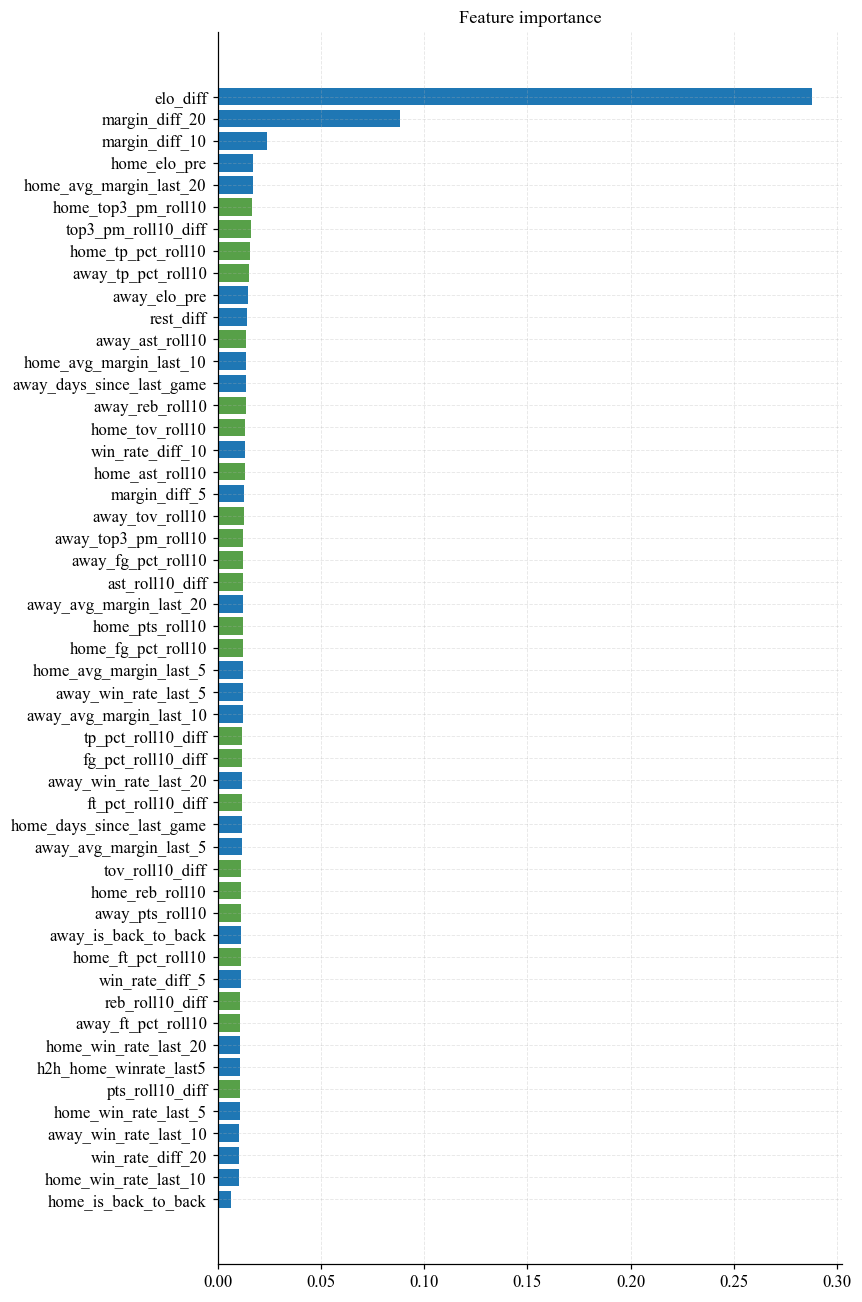


 OLD avg importance: 0.026
NEW avg importance: 0.013


In [38]:
imp = pd.DataFrame({
    "feature": ALL_FEATURES,
    "importance": model_new.feature_importances_,
    "is_new": [f in PLAYER_FEATURES for f in ALL_FEATURES],
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 12))
colors = ["#57A048" if new else "#1f77b4" for new in imp.is_new]
ax.barh(imp.feature, imp.importance, color=colors)
ax.set_title("Feature importance")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n OLD avg importance: {imp[~imp.is_new].importance.mean():.3f}")
print(f"NEW avg importance: {imp[imp.is_new].importance.mean():.3f}")